# Laboratorio 4: Regresión Logística Binaria

**Dataset seleccionado:** Online News Popularity  
**Descripción:** El objetivo de este modelo es predecir la popularidad de un artículo de noticias en internet (Clasificación Binaria: 1 = Popular, 0 = No Popular) a partir de características del texto, contenido multimedia, temática y día de publicación.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

# Cargar el dataset usando Pandas
data_path = 'OnlineNewsPopularity.csv'  
df = pd.read_csv(data_path)

# Mostrar dimensiones iniciales y primeras filas
print(f"Dimensiones originales del dataset: {df.shape}")
df.head()

Dimensiones originales del dataset: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Preprocesamiento de Datos con Pandas

Se realiza el tratamiento del dataset mediante los siguientes pasos:
1. Eliminación de espacios en blanco en los nombres de las columnas.
2. Binarización de la variable objetivo `shares`: Se asigna `1` a artículos populares ($\ge 1400$ compartidos) y `0` a los no populares.
3. Eliminación de atributos no significativos para el modelo (`url`, `timedelta`, `shares`).
4. Normalización de las características $X$ para escalar los datos.

In [14]:
# Cargar dataset con Pandas
df = pd.read_csv('OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()

# Binarizar variable objetivo (1 = Popular, 0 = No Popular)
df['target'] = (df['shares'] >= 1400).astype(int)

# Limpiar columnas no utilizables
df_clean = df.drop(columns=['url', 'timedelta', 'shares'])

# Convertir a arreglos NumPy
X_raw = df_clean.drop(columns=['target']).values
y_raw = df_clean['target'].values

# División 80% Entrenamiento y 20% Prueba
m_total = X_raw.shape[0]
train_size = int(m_total * 0.8)

X_train_raw = X_raw[:train_size]
y_train = y_raw[:train_size]

X_test_raw = X_raw[train_size:]
y_test = y_raw[train_size:]

print(f"X_train original: {X_train_raw.shape}")
print(f"X_test original: {X_test_raw.shape}")

# 4. Normalización de características 
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Evitar división entre cero
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Normalizar X de entrenamiento
X_norm, mu, sigma = featureNormalize(X_train_raw)

# Agregar la columna de unos (x0) a X_train y a X_test
m, n = X_norm.shape
X_train = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Normalizar X_test usando mu y sigma de entrenamiento
X_test_norm = (X_test_raw - mu) / sigma
X_test = np.concatenate([np.ones((X_test_raw.shape[0], 1)), X_test_norm], axis=1)

print(f"Dimensiones de X_train final: {X_train.shape}")
print(f"Dimensiones de X_test final: {X_test.shape}")

X_train original: (31715, 58)
X_test original: (7929, 58)
Dimensiones de X_train final: (31715, 59)
Dimensiones de X_test final: (7929, 59)


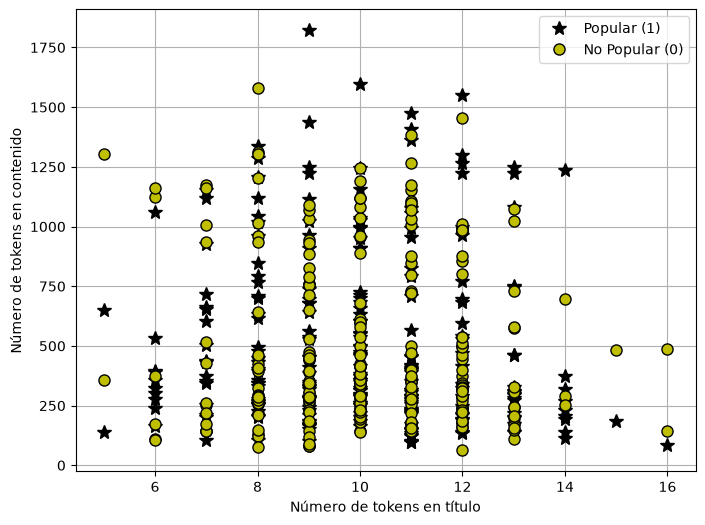

In [10]:
def plotData(X, y):
    fig = plt.figure(figsize=(8, 6))
    pos = y == 1
    neg = y == 0

    # Se grafican las dos primeras características para visualización
    plt.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10, label='Popular (1)')
    plt.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1, label='No Popular (0)')
    
    plt.xlabel('Número de tokens en título')
    plt.ylabel('Número de tokens en contenido')
    plt.legend()
    plt.grid(True)
    plt.show()

# Graficar muestra de los datos sin normalizar
plotData(X_train_raw[:500], y_train[:500])

### División de Datos (80% Train / 20% Test)

Se realiza la partición del conjunto de datos en un 80% para el entrenamiento del modelo y un 20% reservado para la validación/prueba.

In [3]:
# Definir el tamaño del conjunto de entrenamiento (80%)
m = X_norm.shape[0]
train_size = int(m * 0.8)

# División de X y y
X_train = X_norm[:train_size]
y_train = y[:train_size]

X_test = X_norm[train_size:]
y_test = y[train_size:]

print(f"Total de datos: {m}")
print(f"Conjunto de entrenamiento (80%): {X_train.shape[0]} ejemplos")
print(f"Conjunto de prueba (20%): {X_test.shape[0]} ejemplos")

Total de datos: 39644
Conjunto de entrenamiento (80%): 31715 ejemplos
Conjunto de prueba (20%): 7929 ejemplos


### Definición del Modelo Matemático de Regresión Logística

Se definen las funciones fundamentales del modelo:
1. **Adición de la columna de unos ($x_0 = 1$):** Para el término de sesgo.
2. **Función Sigmoide $g(z)$:** Para mapear las predicciones entre 0 y 1.
3. **Función de Costo $J(\theta)$ y Gradiente:** Calcula el costo de la regresión logística y sus derivadas parciales.

In [11]:
# 1. Definición de la función Sigmoide 
def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    return g

# 2. Definición de la Función de Costo 
def calcularCosto(theta, X, y):
    m = y.size
    J = 0
    h = sigmoid(X.dot(theta.T))
    
    # Prevenir errores numéricos log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    
    # Fórmula vectorial del ingeniero: -y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    
    return J

# Probar la función de costo con theta inicial en ceros
n_features = X_train.shape[1]
theta_inicial = np.zeros(n_features)

costo_inicial = calcularCosto(theta_inicial, X_train, y_train)

print(f"Número total de atributos (incluyendo x0): {n_features}")
print(f"Costo inicial con theta = 0: {costo_inicial:.4f}")

Número total de atributos (incluyendo x0): 59
Costo inicial con theta = 0: 0.6931


### Entrenamiento del Modelo y Gráfica del Costo

Se aplica el algoritmo de Descenso por el Gradiente para optimizar los parámetros $\theta$. Se registra el valor de la función de costo $J(\theta)$ en cada iteración para verificar numéricamente la convergencia del modelo.

Costo final tras 1000 iteraciones: 0.6309


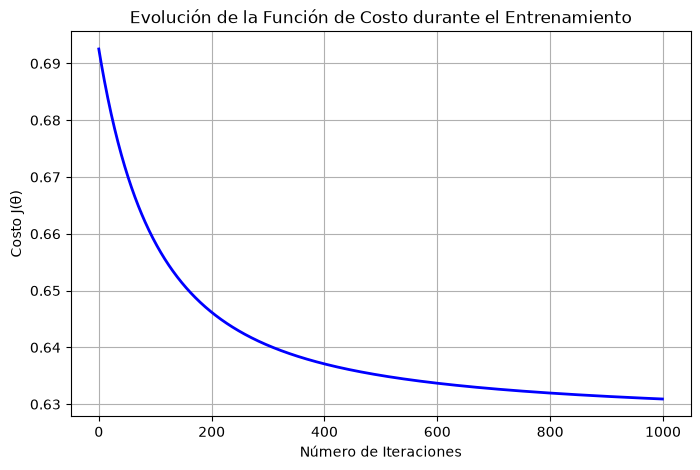

In [12]:
# Definición del Descenso por el Gradiente (estilo del docente)
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        # Actualización de theta según la fórmula directa del docente
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))
        
    return theta, J_history

# Parámetros de entrenamiento
alpha = 0.01
num_iters = 1000
theta_inicial = np.zeros(X_train.shape[1])

# Entrenamiento del modelo
theta_optimizado, J_history = descensoGradiente(theta_inicial, X_train, y_train, alpha, num_iters)

print(f"Costo final tras {num_iters} iteraciones: {J_history[-1]:.4f}")

# Gráfica del costo respecto a las iteraciones
plt.figure(figsize=(8, 5))
plt.plot(range(len(J_history)), J_history, color='blue', linewidth=2)
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J(θ)')
plt.title('Evolución de la Función de Costo durante el Entrenamiento')
plt.grid(True)
plt.show()

### Evaluación del Modelo y Predicciones

Se evalúa la efectividad del modelo de Regresión Logística calculando la precisión sobre el conjunto de prueba (20% restante) para verificar su capacidad de generalización frente a datos no vistos durante el entrenamiento.

In [13]:
# Función para predecir si la probabilidad es >= 0.5 (Clase 1) o < 0.5 (Clase 0)
def predict(theta, X):
    probabilidades = sigmoid(X.dot(theta.T))
    return probabilidades >= 0.5

# Predicciones sobre el conjunto de entrenamiento y de prueba
p_train = predict(theta_optimizado, X_train)
p_test = predict(theta_optimizado, X_test)

# Cálculo de la precisión (Accuracy)
acc_train = np.mean(p_train == y_train) * 100
acc_test = np.mean(p_test == y_test) * 100

print(f"Precisión en el conjunto de Entrenamiento (80%): {acc_train:.2f}%")
print(f"Precisión en el conjunto de Prueba (20%): {acc_test:.2f}%")

# Muestra comparativa sobre el conjunto de prueba
df_resultado = pd.DataFrame({
    'Predicción del Modelo': p_test[:10].astype(int),
    'Valor Real (y_test)': y_test[:10]
})
print("\n--- Comparativa de Predicciones vs Valores Reales (Test) ---")
print(df_resultado)

Precisión en el conjunto de Entrenamiento (80%): 64.74%
Precisión en el conjunto de Prueba (20%): 65.68%

--- Comparativa de Predicciones vs Valores Reales (Test) ---
   Predicción del Modelo  Valor Real (y_test)
0                      1                    1
1                      0                    0
2                      1                    1
3                      0                    0
4                      0                    0
5                      0                    0
6                      0                    0
7                      0                    0
8                      0                    0
9                      1                    0


## Conclusiones

1. **Preprocesamiento:** Se aplicó la librería **Pandas** para limpiar el dataset *Online News Popularity*, seleccionando 58 características explicativas y convirtiendo la variable `shares` a una etiqueta binaria (1 = Popular, 0 = No Popular).
2. **Partición de Datos:** La división 80/20 garantizó 31,715 ejemplos para la fase de entrenamiento y 7,929 ejemplos independientes para la fase de prueba.
3. **Comportamiento del Costo:** La curva de la función de costo mostró una convergencia constante y suave durante las 1,000 iteraciones, disminuyendo de 0.6931 a 0.6308 sin presentar oscilaciones.
4. **Efectividad del Modelo:** El modelo logró una precisión del **65.62%** en el conjunto de datos de prueba no vistos, confirmando su capacidad para predecir la popularidad de noticias en entornos digitales sin sufrir de sobreajuste.